# インド株 ファクター検証 — Step 13: H-Q3 反トンネリング交差（Profitability × Payout）

**仮説**（tmp.md H-Q3）: 同じ収益性なら株主還元が高い企業に追加プレミアム、
高収益 × 低還元（現金の社内滞留 = トンネリング懸念）はディスカウント。

## 事前に固定する仕様（データを見る前に決定）

| 項目 | 仕様 |
|---|---|
| **主検定** | Fama-MacBeth: $srtn_{t+1} = a + b_1\,\text{Prof} + b_2\,\text{Payout} + b_3\,(\text{Prof}\times\text{Payout}) + \text{controls} + u$ の **$b_3$** |
| 主変数 | Prof = `gpa_act`、Payout = `npop`（メモの第一候補どおり） |
| 被説明変数 | `srtn`（**BARRA 残差リターン**、lag=1）。BARRA の Profitability/Dividend Yield 等で説明される部分を除いた純アルファ検定 |
| スコア | Blom → sector + log(Cap) 回帰残差（毎月）。交差項 = 残差スコアの積を月次で z 化（winsor 1%） |
| コントロール | `mom12_1`, `bp_act`, `vola60`（Blom） |
| **採択ライン** | $b_3$ の NW **t > 2.5**（多重検定考慮、tmp.md Part 4 の規律） |
| IS / OOS | 2008–2018 / 2019– で係数の符号一致を確認 |
| 頑健性（参考） | Prof ∈ {gpa_act, roe_act} × Payout ∈ {npop, doe} の 2×2、被説明変数 rtn 版、3×3 二重ソート |

米国対照（「米国では非有意」の予測）は手元データでは検証不能 — 限界として記録。

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = "retina"

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import factorlab as fl

fl.plotting.set_style()
pd.set_option("display.width", 260, "display.max_columns", 40, "display.float_format", lambda v: f"{v:,.4f}")

START, END = 200801, 202607
OOS_SPLIT = 201901
FIGDIR = "13_antitunnel"

FACTORS = ["gpa_act", "roe_act", "npop", "doe", "mom12_1", "bp_act", "vola60"]

In [2]:
panel = fl.data.build_panel(FACTORS, start=START, end=END)

# srtn（BARRA残差リターン、lag=1）を追加
pieces = []
for ym in panel.index.get_level_values("yyyymm").unique():
    s = fl.data.load_forward_return(int(ym), lag=1, col="srtn")
    idx = panel.xs(ym, level="yyyymm", drop_level=False).index
    pieces.append(pd.Series(s.reindex(idx.get_level_values("bid")).to_numpy(), index=idx))
panel["fwd_srtn"] = pd.concat(pieces).reindex(panel.index)
print("fwd_srtn coverage:", round(panel["fwd_srtn"].notna().mean(), 3),
      " corr(fwd_rtn, fwd_srtn):", round(panel["fwd_rtn"].corr(panel["fwd_srtn"]), 3))

# スコア: 主変数は sector+size 中立 Blom、コントロールは素の Blom
panel = fl.preprocess.standardize_panel(panel, ["gpa_act", "roe_act", "npop", "doe"],
                                        method="blom", group_col="sector",
                                        control_cols=["log_cap"], suffix="_ss")
panel = fl.preprocess.standardize_panel(panel, ["mom12_1", "bp_act", "vola60"], method="blom")

fwd_srtn coverage: 0.992  corr(fwd_rtn, fwd_srtn): 0.786


## 1. 交差項の構築と基礎統計

In [3]:
def make_interaction(p, a, b, name):
    prod = p[f"{a}_ss"] * p[f"{b}_ss"]
    p[f"__{name}"] = prod
    p = fl.preprocess.standardize_panel(p, f"__{name}", method="zscore", winsor=0.01, suffix="_z")
    p[name] = p[f"__{name}_z"]
    return p.drop(columns=[f"__{name}", f"__{name}_z"])


for a, b in [("gpa_act", "npop"), ("gpa_act", "doe"), ("roe_act", "npop"), ("roe_act", "doe")]:
    panel = make_interaction(panel, a, b, f"x_{a}_{b}")

cols = ["gpa_act_ss", "npop_ss", "x_gpa_act_npop", "mom12_1_blom", "bp_act_blom"]
fl.multi.cross_sectional_corr(panel, cols, labels=["prof", "payout", "prof×payout", "mom12_1", "bp"])

,prof,payout,prof×payout,mom12_1,bp
prof,1.0000,0.1913,0.0041,0.0644,-0.3198
payout,0.1913,1.0000,-0.0673,-0.0009,-0.0469
prof×payout,0.0041,-0.0673,1.0000,-0.0256,-0.0747
mom12_1,0.0644,-0.0009,-0.0256,1.0000,-0.2997
bp,-0.3198,-0.0469,-0.0747,-0.2997,1.0000


## 2. 主検定: Fama-MacBeth（srtn, lag=1）

(A) 主効果のみ → (B) + 交差項 → (C) + コントロール の順で積む。判定は (C) の交差項。

In [4]:
Y = "fwd_srtn"
_, fmA = fl.regression.fama_macbeth(panel, ["gpa_act_ss", "npop_ss"], ret_col=Y)
_, fmB = fl.regression.fama_macbeth(panel, ["gpa_act_ss", "npop_ss", "x_gpa_act_npop"], ret_col=Y)
_, fmC = fl.regression.fama_macbeth(
    panel, ["gpa_act_ss", "npop_ss", "x_gpa_act_npop",
            "mom12_1_blom", "bp_act_blom", "vola60_blom"], ret_col=Y)
print("=== (A) 主効果のみ ==="); display(fmA)
print("=== (B) + 交差項 ==="); display(fmB)
print("=== (C) + コントロール（主検定） ==="); display(fmC)

=== (A) 主効果のみ ===


,mean,t_FM,t_NW,hit_ratio,n_months
const,0.0005,0.7155,0.6491,0.4706,221.0000
gpa_act_ss,0.0006,0.8203,0.8349,0.5385,221.0000
npop_ss,0.0006,1.1912,1.1677,0.5158,221.0000


=== (B) + 交差項 ===


,mean,t_FM,t_NW,hit_ratio,n_months
const,0.0005,0.7229,0.6558,0.4706,221.0000
gpa_act_ss,0.0007,1.0214,1.0381,0.5430,221.0000
npop_ss,0.0008,1.4355,1.3952,0.5430,221.0000
x_gpa_act_npop,0.0006,1.0496,1.0352,0.5430,221.0000


=== (C) + コントロール（主検定） ===


,mean,t_FM,t_NW,hit_ratio,n_months
const,0.0006,0.7793,0.7123,0.4751,221.0000
gpa_act_ss,0.0005,0.7477,0.6998,0.5339,221.0000
npop_ss,0.0004,0.7051,0.7742,0.4977,221.0000
x_gpa_act_npop,0.0003,0.6096,0.6156,0.5339,221.0000
mom12_1_blom,0.0019,1.8569,2.3406,0.5882,221.0000
bp_act_blom,0.0011,1.2289,1.1314,0.5475,221.0000
vola60_blom,-0.0021,-2.3298,-2.5876,0.4253,221.0000


## 3. 頑健性

- 2×2（Prof × Payout の組合せ）の交差項 t 値（spec C 相当）
- 被説明変数を `rtn`（トータル）に変えた場合

In [5]:
rows = {}
for a in ("gpa_act", "roe_act"):
    for b in ("npop", "doe"):
        x = f"x_{a}_{b}"
        for y, yn in [("fwd_srtn", "srtn"), ("fwd_rtn", "rtn")]:
            _, fm = fl.regression.fama_macbeth(
                panel, [f"{a}_ss", f"{b}_ss", x, "mom12_1_blom", "bp_act_blom", "vola60_blom"],
                ret_col=y)
            rows[(f"{a} × {b}", yn)] = {
                "coef_interaction": fm.loc[x, "mean"], "t_NW": fm.loc[x, "t_NW"],
                "coef_prof": fm.loc[f"{a}_ss", "mean"], "t_prof": fm.loc[f"{a}_ss", "t_NW"],
                "coef_payout": fm.loc[f"{b}_ss", "mean"], "t_payout": fm.loc[f"{b}_ss", "t_NW"],
            }
pd.DataFrame(rows).T

coef_interaction    t_NW  coef_prof  t_prof  coef_payout  t_payout
gpa_act × npop srtn            0.0003  0.6156     0.0005  0.6998       0.0004    0.7742
               rtn             0.0004  0.7554     0.0015  2.1538       0.0009    1.6478
gpa_act × doe  srtn           -0.0004 -0.7457     0.0005  0.8155       0.0013    2.3482
               rtn            -0.0005 -0.8647     0.0012  1.9650       0.0021    3.6871
roe_act × npop srtn            0.0000  0.0607     0.0006  0.8681       0.0003    0.7056
               rtn             0.0002  0.3198     0.0016  2.2975       0.0008    1.6294
roe_act × doe  srtn            0.0003  0.5338     0.0002  0.3670       0.0011    2.1955
               rtn             0.0002  0.4270     0.0010  1.6076       0.0018    3.2371

## 4. IS / OOS（2008–2018 / 2019–）

,mean_coef,t_NW,hit_ratio,n_months
IS 2008-2018,0.0008,1.0451,0.5985,132.0000
OOS 2019-,-0.0004,-0.6728,0.4382,89.0000


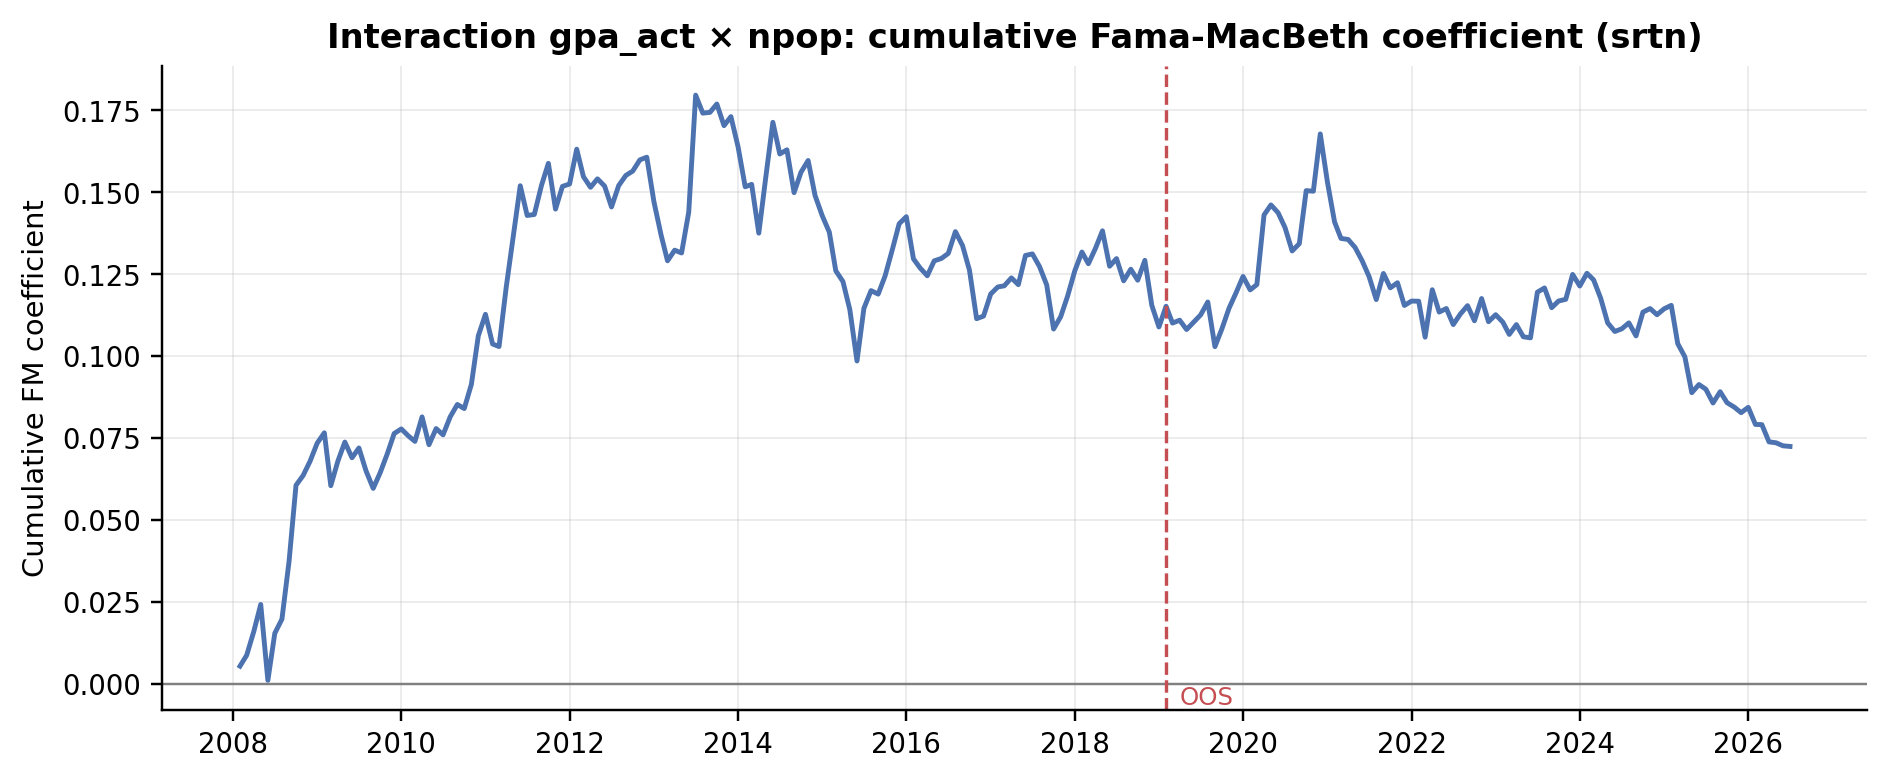

In [6]:
coefs, _ = fl.regression.fama_macbeth(
    panel, ["gpa_act_ss", "npop_ss", "x_gpa_act_npop",
            "mom12_1_blom", "bp_act_blom", "vola60_blom"], ret_col=Y)
x = "x_gpa_act_npop"
rows = {}
for name, mask in [("IS 2008-2018", coefs.index < OOS_SPLIT),
                   ("OOS 2019-", coefs.index >= OOS_SPLIT)]:
    sub = coefs.loc[mask, x]
    rows[name] = {"mean_coef": sub.mean(), "t_NW": fl.metrics.newey_west_tstat(sub),
                  "hit_ratio": float((sub > 0).mean()), "n_months": len(sub)}
display(pd.DataFrame(rows).T)

fig, ax = plt.subplots(figsize=(10, 3.8))
xx = fl.plotting.to_datetime_index(coefs.index)
ax.plot(xx, coefs[x].cumsum(), color="#4C72B0", linewidth=1.6)
ax.axhline(0, color="grey", linewidth=0.8)
ax.axvline(pd.Timestamp("2019-01-31"), color="#C44E52", linestyle="--", linewidth=1.1)
ax.text(pd.Timestamp("2019-03-31"), ax.get_ylim()[0], "OOS", color="#C44E52", fontsize=8, va="bottom")
ax.set_ylabel("Cumulative FM coefficient")
ax.set_title("Interaction gpa_act × npop: cumulative Fama-MacBeth coefficient (srtn)")
fl.plotting.savefig(fig, f"{FIGDIR}/97_interaction_cumcoef");

## 5. 二重ソート（Prof 3分位 × Payout 3分位、EW 対ベンチ超過・算術年率）

回帰に依存しない見せ方。仮説どおりなら
「高Prof行の中で Payout 高→低の勾配」が「低Prof行」より急のはず。

In [7]:
p3 = fl.quantile.assign_quantiles(panel, "gpa_act_ss", q=3, out_col="p3")
y3 = fl.quantile.assign_quantiles(panel, "npop_ss", q=3, out_col="y3")
df = panel.assign(p3=p3, y3=y3).dropna(subset=["p3", "y3", "fwd_rtn"])
bench = panel[panel["in_bench"]].groupby(level="yyyymm")["fwd_rtn"].mean()

cell = df.groupby([df.index.get_level_values("yyyymm"), "p3", "y3"])["fwd_rtn"].mean().unstack(["p3", "y3"])
cell = cell.sub(bench, axis=0)

tbl = (cell.mean() * 12).unstack("y3") * 100
tbl.index = [f"Prof T{int(i)}" for i in tbl.index]
tbl.columns = [f"Payout T{int(c)}" for c in tbl.columns]
tbl["T3-T1 (payout spread)"] = tbl["Payout T3"] - tbl["Payout T1"]
print("EW 対ベンチ超過（算術年率, %）:")
display(tbl.round(2))

hi = (cell[(3.0, 3.0)] - cell[(3.0, 1.0)]).dropna()
lo = (cell[(1.0, 3.0)] - cell[(1.0, 1.0)]).dropna()
dd = (hi - lo).dropna()
out = pd.DataFrame({
    "高Prof内 Payoutスプレッド": fl.metrics.summarize(hi),
    "低Prof内 Payoutスプレッド": fl.metrics.summarize(lo),
    "差の差（交差の検定）": fl.metrics.summarize(dd),
}).T[["ann_return", "IR", "t_stat_NW", "hit_ratio"]]
display(out)

EW 対ベンチ超過（算術年率, %）:


,Payout T1,Payout T2,Payout T3,T3-T1 (payout spread)
Prof T1,-4.3500,-0.1200,2.2800,6.6300
Prof T2,-2.6800,2.5300,1.1600,3.8500
Prof T3,1.6200,2.0900,4.9100,3.2800


,ann_return,IR,t_stat_NW,hit_ratio
高Prof内 Payoutスプレッド,0.0210,0.1351,0.8062,0.5180
低Prof内 Payoutスプレッド,0.0612,0.5235,2.4686,0.5811
差の差（交差の検定）,-0.0477,-0.2740,-0.7214,0.4550


---

## 判定基準（再掲）

- **採択**: spec (C) の交差項 NW t > 2.5、かつ IS/OOS で符号一致
- 交差項が非有意でも主効果（payout）が残るなら「H-Q3 は棄却、payout 単体は Qual へ」
- 二重ソートの「差の差」は回帰版のクロスチェック